In [1]:
import numpy as np

In [2]:
notT = False

def plot_simulation_spec(sim):
    import matplotlib.pyplot as plt

    Z = np.log(np.abs(sim.spec['result'])**2)
    x = np.unique(sim.spec['A'])
    y = np.unique(sim.spec['B'])

    # if Z.shape == (len(y), len(x)) -> no transpose; if Z.shape == (len(x), len(y)) -> transpose
    # matplotlib expects [y, x] ordering for images
    if Z.shape == (len(y), len(x)) and notT:
        print('\nNOT transposing\n')
        toplot = Z
    else:
        print('\ntransposing\n')
        toplot = Z.T

    plt.pcolormesh(x, y, toplot, shading="auto")
    plt.xlabel('A')
    plt.ylabel('B')
    plt.colorbar(label='log intensity')
    plt.show()

# Evaluation workflow demonstration

In [3]:
import wilson_suite as ws

from wilson_suite.wilson_main.wf import WilsonSimulation
# from wilson_suite.wilson_main.workflow_abstractions import WilsonSimulation

from CQCParse.utils import PKG_ROOT as CQCPARSE_ROOT

## Experiment and possible spectral axes

In [4]:
evv_experiment_obj = ws.fixtures.evv_experiment()
evv_experiment_obj # can there be a better way to show details of an experiment?

VibExperiment(order=3, field=ElectricField(pulses=(EmPulse(env='impulsive', maxstr=1e-05, tc=50.0, cf=0.0, cf_uv=0.0, dev=None, wv=[0.0, 0.0, 1.0], pol=[1.0, 0.0, 0.0], overall_phase=(1+0j), id=1), EmPulse(env='impulsive', maxstr=1e-05, tc=100.0, cf=0.0, cf_uv=0.0, dev=None, wv=[0.0, 0.0, 1.0], pol=[1.0, 0.0, 0.0], overall_phase=(1+0j), id=2), EmPulse(env='impulsive', maxstr=1e-05, tc=120.0, cf=0.0, cf_uv=0.072, dev=None, wv=[0.0, 0.0, 1.0], pol=[1.0, 0.0, 0.0], overall_phase=(1+0j), id=3))), detector=SpecDetector(detection_method='freq', detector_location=(0.0, 0.0, 1.0), detection_polarization=(1.0, 0.0, 0.0), detection_range=[0.003, 0.0031, 0.0032, 0.0033, 0.0034000000000000002, 0.0035, 0.0036, 0.0037, 0.0038, 0.0039000000000000003, 0.004, 0.0041, 0.004200000000000001, 0.0043, 0.0044, 0.0045000000000000005, 0.0046, 0.0047, 0.0048000000000000004, 0.0049, 0.005, 0.0051, 0.0052, 0.0053, 0.0054, 0.0055, 0.005600000000000001, 0.0057, 0.0058, 0.005900000000000001, 0.006, 0.0061, 0.0062000

In [5]:
help(evv_experiment_obj) # no info on indep_vars or valid_axis_combs

Help on VibExperiment in module wilson_suite.wilson_experiment.abstractions object:

class VibExperiment(builtins.object)
 |  VibExperiment(order: int, field: wilson_suite.wilson_experiment.abstractions.ElectricField, detector: wilson_suite.wilson_experiment.abstractions.SpecDetector, scans: list[wilson_suite.wilson_experiment.abstractions.SpecScan] = None, magn_conditions: list = <factory>) -> None
 |
 |  Class to represent a vibrational wave-mixing experiment
 |
 |  ----
 |  field: ElectricField instance: A "base" perturbing field (upon which scans may be imposed)
 |  detector: SpecDetector instance: The detector for this experiment
 |  scans: List of SpecScan instances: Tells which parameters will be scanned over (and how) in this experiment
 |  magn_conditions: List of lists [[sign*pulse i (is always of lower frequency than...), sign*pulse j], ...]:
 |  Magnitude conditions for later use in identifying terms that will not become fully resononant in this experiment
 |
 |  Methods de

In [6]:
evv_experiment_obj.indep_vars # hmmmm, what is the meaning of this dictionary

{0: [[(-1,), (2,)]]}

In [7]:
evv_experiment_obj.valid_axis_combs # hmmmm, what is the meaning of this dictionary

{((-1,), (2,)): [{'A': [(-1,)], 'B': [(-1,), (2,)]},
  {'A': [(-1,)], 'B': [(2,)]},
  {'A': [(2,)], 'B': [(-1,)]},
  {'A': [(2,)], 'B': [(-1,), (2,)]}]}

In [8]:
axes_choice = evv_experiment_obj.valid_axis_combs[((-1,), (2,))][3]
axes_choice

{'A': [(2,)], 'B': [(-1,), (2,)]}

## Derived terms

In [9]:
terms = ws.derive.main.get_fully_enhanced_terms(experiment=evv_experiment_obj)
terms # hmmmm, what is the meaning of this dictionary
#  0: {(0, 0): []} -- doesn't make sense to have? also, will it ever be not empty?

{1: {(1,
   0): [VibPerturbedTerm(coeff = -1/4, props = [PolProp(ops = [QOperator(o = 1, op_type = None, ax = None)], dord = 1, (inds = ['a'])), PolProp(ops = [QOperator(o = 2, op_type = None, ax = None)], dord = 1, (inds = ['b'])), PolProp(ops = [QOperator(o = 0, op_type = None, ax = None), QOperator(o = 3, op_type = None, ax = None)], dord = 2, (inds = ['a', 'b']))], freqterms = [[sl=omega_['a'], sr=omega_[]], pert_wf=F, [sl=omega_['b'], sr=omega_[]], pert_wf=F], res = [ResCond(diff = [sl=omega_[], sr=omega_['a']], pert_wf=F, pf = [-1], id = None), ResCond(diff = [sl=omega_['b'], sr=omega_['a']], pert_wf=F, pf = [-1, 2], id = None)]), VibPerturbedTerm(coeff = -1/4, props = [PolProp(ops = [QOperator(o = 0, op_type = None, ax = None), QOperator(o = 3, op_type = None, ax = None)], dord = 1, (inds = ['b'])), PolProp(ops = [QOperator(o = 1, op_type = None, ax = None)], dord = 1, (inds = ['a'])), PolProp(ops = [QOperator(o = 2, op_type = None, ax = None)], dord = 2, (inds = ['a', 'b']))], 

In [10]:
evv_terms = ws.derive.term_var_translate.translate_terms_to_axis_variables(terms, axes_choice)
evv_terms
#  0: {(0, 0): []} -- doesn't make sense to have? also, will it ever be not empty?

{1: {(1,
   0): [VibPerturbedTerm(coeff = -1/4, props = [PolProp(ops = [QOperator(o = 1, op_type = None, ax = None)], dord = 1, (inds = ['a'])), PolProp(ops = [QOperator(o = 2, op_type = None, ax = None)], dord = 1, (inds = ['b'])), PolProp(ops = [QOperator(o = 0, op_type = None, ax = None), QOperator(o = 3, op_type = None, ax = None)], dord = 2, (inds = ['a', 'b']))], freqterms = [[sl=omega_['a'], sr=omega_[]], pert_wf=F, [sl=omega_['b'], sr=omega_[]], pert_wf=F], res = [ResCond(diff = [sl=omega_[], sr=omega_['a']], pert_wf=F, pf = ['-A', 'B'], id = None), ResCond(diff = [sl=omega_['b'], sr=omega_['a']], pert_wf=F, pf = ['B'], id = None)]), VibPerturbedTerm(coeff = -1/4, props = [PolProp(ops = [QOperator(o = 0, op_type = None, ax = None), QOperator(o = 3, op_type = None, ax = None)], dord = 1, (inds = ['b'])), PolProp(ops = [QOperator(o = 1, op_type = None, ax = None)], dord = 1, (inds = ['a'])), PolProp(ops = [QOperator(o = 2, op_type = None, ax = None)], dord = 2, (inds = ['a', 'b']

## Calculation/simulation setup

In [11]:
mol_system = ws.main.abstractions.MolecularSystem(name='FORM', natoms=4)
vib_ana = ws.main.abstractions.VibAnaSetup(system=mol_system, regime='GVPT2', vibana_own_analysis='none')
calc_setup = ws.main.abstractions.DataOriginInfo(source_type='gaussian', 
                                                    lvl_theory='B3LYP', 
                                                    basis_set='cc-pVQZ', 
                                                    base_file_loc=CQCPARSE_ROOT+'/CQCParse/files_examples/dftGaussian/FORM/B3LYPcc_pVQZ/g16_inputFull_3q.out')

In [12]:
help(vib_ana)

Help on VibAnaSetup in module wilson_suite.wilson_main.abstractions object:

class VibAnaSetup(builtins.object)
 |  VibAnaSetup(regime: str = None, system: wilson_suite.wilson_main.abstractions.MolecularSystem = None, regime_subinfo: dict = None, vibana_own_analysis: str = 'full', max_state_lvl: int = None, states: list[wilson_suite.wilson_main.abstractions.VibState] = None, nc_sqrt_eigval: dict = None, nc_eigvec: dict = None, exclude_modes: list = None, diagn: dict = None) -> None
 |
 |  Class for setup for vibrational analysis and storage of the resulting information
 |
 |      ----
 |      regime: string: Vibrational analysis regime (e.g. "harmonic", "GVPT2", "VPT2")
 |      system: MolecularSystem instance: System to which this instance pertains
 |      regime_subinfo: dictionary: Extra configuration info for vibrational regime (e.g. skip rotational effects)
 |      max_state_lvl: integer: Maximum number of vibrational quanta per harmonic state involved in states
 |      states: Li

In [13]:
bounds_dict = {'A': (0., 5000.), 'B': (0., 5000.)}
box = ws.intensities.amplitudes.spectrum_composition.Box(bounds_dict)
spectral_window = ws.intensities.amplitudes.spectrum_composition.SpectralWindow(box=box)

evi = ws.main.spectrum_abstractions.EvaluationInfo(**{'spectral_window': spectral_window,
                                                        'Gamma': 4.7, 'Gamma_unit': 'cm-1',
                                                        'grid_resolution': {'A': 10, 'B': 10}})
spec_eval_setup = ws.main.spectrum_abstractions.SpecEvalSetup(ev_info=evi)

### Making a `WilsonSimulation` instance

In [14]:
simulation = WilsonSimulation()
simulation.terms = evv_terms
simulation.system = mol_system
simulation.exp = evv_experiment_obj
simulation.vib_ana_setup = vib_ana
simulation.spec_eval_setup = spec_eval_setup

#### Preparing `simulation.props`

In [15]:
simulation.addPropEvalSetup(eval_uniform=calc_setup)
simulation.setPropsAndMaxStateLvl() # setting up self.props/sim.props
simulation.dressPropsWithSetup()

In [16]:
simulation.getResults(obtainer=ws.utils.wilson_data_obtainer)

In [17]:
print(simulation.is_ready)
print(simulation.is_configured)

True
True


In [18]:
import copy
copy_props = copy.deepcopy(simulation.props)

simulation.props = []
print(simulation.is_ready)

simulation.props = copy_props

not len(self.props) > 0
False


In [19]:
simulation.vib_ana_setup.states

[VibState(harm_quanta_coeffs={('0',): 1.0}, energy=2726.813, displacement=None, serial_harm_quanta_coeffs={'0': 1.0}, state_label='0', harmonic_WF=None),
 VibState(harm_quanta_coeffs={('1',): 1.0}, energy=1794.54, displacement=None, serial_harm_quanta_coeffs={'1': 1.0}, state_label='1', harmonic_WF=None),
 VibState(harm_quanta_coeffs={('2',): 1.0}, energy=1501.586, displacement=None, serial_harm_quanta_coeffs={'2': 1.0}, state_label='2', harmonic_WF=None),
 VibState(harm_quanta_coeffs={('3',): 1.0}, energy=1185.288, displacement=None, serial_harm_quanta_coeffs={'3': 1.0}, state_label='3', harmonic_WF=None),
 VibState(harm_quanta_coeffs={('4',): 1.0}, energy=2682.765, displacement=None, serial_harm_quanta_coeffs={'4': 1.0}, state_label='4', harmonic_WF=None),
 VibState(harm_quanta_coeffs={('5',): 1.0}, energy=1247.878, displacement=None, serial_harm_quanta_coeffs={'5': 1.0}, state_label='5', harmonic_WF=None),
 VibState(harm_quanta_coeffs={('0', '0'): 1.0}, energy=5390.225, displacement

#### Evaluate


```python
    def evaluate(self):
        from ..wilson_intensities.amplitudes.evaluation_wf import make_evaluation_inputs
        eval_inputs = make_evaluation_inputs(simulation=self)
        workflow = EvaluationWorkflow(inputs=eval_inputs)
        self._workflow = workflow

        self.spec  = workflow.run()
```

### Running `simulation.evaluate()`

In [20]:
# hides all evaluation workflow
simulation.evaluate()

In [21]:
np.set_printoptions(linewidth=380, precision=1)
simulation.spec['result']

array([[ 0.0e+00+0.0e+00j,  0.0e+00+0.0e+00j,  0.0e+00+0.0e+00j,  0.0e+00+0.0e+00j,  0.0e+00+0.0e+00j,  0.0e+00+0.0e+00j,  0.0e+00+0.0e+00j,  0.0e+00+0.0e+00j,  0.0e+00+0.0e+00j,  0.0e+00+0.0e+00j],
       [ 0.0e+00+0.0e+00j,  0.0e+00+0.0e+00j,  0.0e+00+0.0e+00j,  0.0e+00+0.0e+00j,  0.0e+00+0.0e+00j,  0.0e+00+0.0e+00j,  0.0e+00+0.0e+00j,  0.0e+00+0.0e+00j,  0.0e+00+0.0e+00j,  0.0e+00+0.0e+00j],
       [-6.1e+01-1.5e+03j,  3.4e+00-5.6e-02j,  0.0e+00+0.0e+00j,  0.0e+00+0.0e+00j,  0.0e+00+0.0e+00j,  0.0e+00+0.0e+00j,  0.0e+00+0.0e+00j,  0.0e+00+0.0e+00j,  0.0e+00+0.0e+00j,  0.0e+00+0.0e+00j],
       [ 2.9e+02+1.1e+04j, -3.2e+02+4.7e+02j, -1.3e+00+2.0e-02j,  0.0e+00+0.0e+00j,  0.0e+00+0.0e+00j,  0.0e+00+0.0e+00j,  0.0e+00+0.0e+00j,  0.0e+00+0.0e+00j,  0.0e+00+0.0e+00j,  0.0e+00+0.0e+00j],
       [ 6.1e+02+1.4e+04j,  8.5e+00-1.6e+02j,  5.8e+01+2.2e+00j, -1.1e+00-1.0e-01j,  0.0e+00+0.0e+00j,  0.0e+00+0.0e+00j,  0.0e+00+0.0e+00j,  0.0e+00+0.0e+00j,  0.0e+00+0.0e+00j,  0.0e+00+0.0e+00j],
     


transposing



/tmp/ipykernel_794705/738247638.py:6: RuntimeWarning: divide by zero encountered in log
  Z = np.log(np.abs(sim.spec['result'])**2)


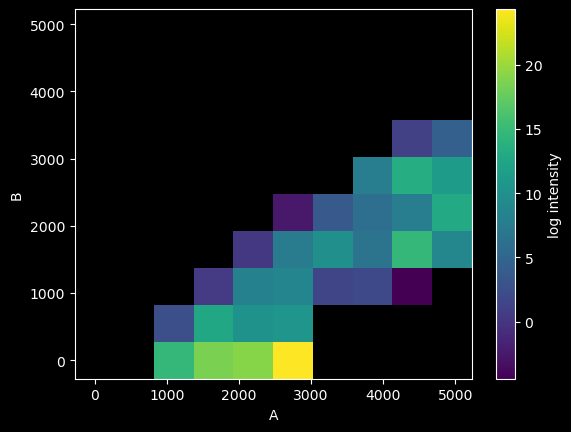

In [22]:
plot_simulation_spec(simulation)

# `EvaluationWorkflow` using a prepared `WilsonSimulation`

In [23]:
eval_inputs = ws.intensities.amplitudes.evaluation_wf.make_evaluation_inputs(simulation=simulation)

workflow = ws.intensities.amplitudes.evaluation_wf.EvaluationWorkflow(inputs=eval_inputs)
spec_info = workflow.run()

```python
    def run(self):
        """
        Run evaluation, return dict with axes and results grid
        """
        self._validate_inputs()
        
        try:
            # Step 1: Preparation
            with self.step("prep_terms"):
                self.artifacts.terms = prepTermsForEval(self.inputs.terms)

            with self.step("prep_data"): # could be in data inputs
                self.artifacts.vib_data, self.artifacts.vibdiff_cache, self.artifacts.data_configs = prepDataForEval(self.inputs.number_of_modes, 
                                                                 self.inputs.pulse_polarization_vector, 
                                                                 self.inputs.vib_ana_setup, 
                                                                 self.inputs.props)

            # self._save_checkpoint('Step1')  # Save checkpoint

            # Step 2: Process resonances and calculate coefficients
            # get resonances locations for all terms
            with self.step("process_resonances"):
                self.artifacts.motif_locs, self.artifacts.terms_for_motifs = process_resonance_motifs(self.artifacts.terms,
                                                                                                            self.artifacts.vib_data,
                                                                                                            self.artifacts.vibdiff_cache)
            with self.step("term_coefficients"):
                self.artifacts.need_precalc = identify_precalc_unique_coeff_parts(terms=self.artifacts.terms)
                self.artifacts.precalculated = precalculate_unique_coeff_parts(
                    need_to_precalc=self.artifacts.need_precalc, data_and_configs=self.artifacts.data_configs)
                self.artifacts.coefficients = evaluate_terms_coeffs(self.artifacts.terms,
                                                                       self.artifacts.motif_locs,
                                                                       self.artifacts.data_configs,
                                                                       self.artifacts.precalculated)

            # self._save_checkpoint('Step2')  # Save checkpoint

            # Step 3: Extract features and place them in the spectral window
            with self.step("all_features"):
                if self.inputs.spec_eval_setup.ev_info.Gamma_unit == 'au':
                    gamma = convNu2Ene(self.inputs.spec_eval_setup.ev_info.Gamma, reverse=True)
                elif self.inputs.spec_eval_setup.ev_info.Gamma_unit == 'cm-1':
                    gamma = self.inputs.spec_eval_setup.ev_info.Gamma
                else:
                    raise ValueError('Gamma cannot be converted from the given unit to au')
                # lineshape_parameter here is goint to be a single float now and be the same(uniform) for all features
                self.artifacts.features = get_features_to_draw(motif_res_loc=self.artifacts.motif_locs, 
                                                                  terms_for_motifs=self.artifacts.terms_for_motifs,
                                                                  term_coeffs_per_index=self.artifacts.coefficients,
                                                                  lineshape_parameter=gamma)
            with self.step("place_in_specwindow"):
                self.artifacts.spec_window = SpectralFeature.filter_to_spec_window(self.artifacts.features, self.inputs.spec_eval_setup.ev_info.spectral_window)
            
            # self._save_checkpoint('Step3')  # Save checkpoint

            # Step 4: Grid management and region evaluation
            with self.step("make_grid_manager"):
                self.artifacts.grid_manager = GridManager(self.artifacts.spec_window)
                self.artifacts.grid_manager.make_fullgrid(self.inputs.spec_eval_setup.ev_info.grid_resolution)

            with self.step("make_regions"):
                self.artifacts.regions = self.artifacts.grid_manager.create_regions()

            with self.step("regions_results"):
                if self.inputs.spec_eval_setup.ev_info.Gamma_unit == 'cm-1':
                    gamma = convNu2Ene(self.inputs.spec_eval_setup.ev_info.Gamma)
                elif self.inputs.spec_eval_setup.ev_info.Gamma_unit == 'au':
                    gamma = self.inputs.spec_eval_setup.ev_info.Gamma
                else:
                    raise ValueError('Gamma cannot be converted from the given unit to au')
                self.artifacts.regions_results = evaluate_regions(self.artifacts.regions, 
                                                                     self.artifacts.vib_data, 
                                                                     self.artifacts.vibdiff_cache,
                                                                     gamma,
                                                                     self.ctx.verbose)

            # self._save_checkpoint('Step4')  # Save checkpoint

            # Step 5: Assemble the full grid
            with self.step("place_results"):
                self.artifacts.grid_manager.place_results_into_grid(self.artifacts.regions_results)

            # Return results
            return self.artifacts.grid_manager.full_grid
            
        except Exception as e:
            raise type(e)(
                f"Failed at '{self.ctx.failed_at}': {e}"
            ) from e
```

In [24]:
results = workflow.artifacts

In [25]:
features = results.features

## Steps of the evaluation workflow:

- Step 0: `self._validate_inputs()` - check if `WilsonSimulation` has everything needed for the evaluation.
- Step 1: `prep_terms` - make a flat list of `VibPerturbedTerm` from `WilsonSimulation.terms`.
- Step 2: `prep_data` 
  - 1) prepare "inclusion list" of normal mode labels 
  - 2) make an instances of `VibStatesData`, `VibDiffCache`, `MolPropsCollection`, and `EvaluationDataAndConfigs`
- Step 3: `process_resonances` - makes 2 mappings:
   - `motif_res_loc` (`ResLocGeoObject`(value) to `ResonanceMotif`(key))
   - `terms_for_motifs` (`list['VibPerturbedTerm']`(value) to `ResonanceMotif`(key)) 
- Step 4: `term_coefficients` 
   - 1) identify what to precalculate and precalculate 
   - 2) make a mapping of a collection of info `dict[ParameterSet, 'apl_coeff as float']]` to  `'VibPerturbedTerm'`   
- Step 5: `all_features` - make a `list[SpectralFeature]` for all res.locations for given terms
- Step 6: `place_in_specwindow` - identify `SpectralFeature`s within `SpectralWindow` and the ones contributing to it (based on dynamic range and lineshape parameter - #TODO)
- Step 7: `make_grid_manager` - make a `GridManager` instance and also `make_fullgrid()` so there is an attribute `GridManager.full_grid`
- Step 8: `make_regions` - make  `GridRegion`s from the full grid based on features clustering:
  - 1) Use `spec_window.find_clusters_by_featboxes()` to make clusters of features based on the overlap of the `SpectralFeature.feat_box` which by now should be set (based on dynamic range and lineshape parameter - #TODO)
  - 2) Cut `full_grid` into subgrids 
  - 3) register these subgrids into `GridRegion`s

- Step 9: `regions_results` - the last layer is `_evaluate_feature()` where the amplitude coefficient is multiplied by the grid evaluated res_motifs (`self.physics.evaluate_compiled_group(group, coords)` for a group per different res_motif found in `SpectralFeature.term_contributions`)
  - 1) for region in regions - `_evaluate_region()`
  - 2) for feature in region.features - `_evaluate_feature()`
  - 3) for compiled_group - `evaluate_compiled_group()`
- Step 10: `place_results` - takes `regions_results` and places them according to indices information for each region into the right places back in the `full_grid`



Part 1:
- step("prep_terms")
- step("prep_data")

Part 2:
- step("process_resonances")
- step("term_coefficients")

Part 3:
- step("all_features")
- step("place_in_specwindow")

Part 4:
- step("make_grid_manager")
- step("make_regions")
- step("regions_results")

Part 5:
- step("place_results")

## Visualizing features, clusters, domains, regions

### Features (result from Step 5)

In [26]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

In [27]:
features = results.features

In [28]:
def plot_features(
    ax,
    features,
    region=None,
    annotate=False,
    point_size=30,
    point_label="feat.location",
    box_label="feat.feat_box",
):
    """
    Plot SpectralFeature objects.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
    features : iterable
        SpectralFeature objects
    region : dict or None
        Optional zoom region:
        {
            "xlim": (xmin, xmax),
            "ylim": (ymin, ymax),
        }
        If None, autoscale to all features.
    annotate : bool
        Annotate visible points and boxes
    """

    # ---- apply region zoom if given ----
    if region is not None:
        ax.set_xlim(*region["xlim"])
        ax.set_ylim(*region["ylim"])

    # Get current visible limits (autoscale or zoom)
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    for feat in features:
        x, y = feat.location["A"], feat.location["B"]

        # ---- point ----
        ax.scatter(
            x, y,
            s=point_size,
            c="red" if feat.amplitude_coeff > 0 else "blue",
            alpha=0.7,
            zorder=3,
        )

        # annotate point if visible
        if annotate and xmin <= x <= xmax and ymin <= y <= ymax:
            ax.annotate(
                point_label,
                (x, y),
                xytext=(6, 6),
                textcoords="offset points",
                fontsize=9,
                fontweight="bold",
                bbox=dict(
                    boxstyle="round,pad=0.2",
                    fc="white",
                    alpha=0.7,
                    edgecolor="none",
                ),
                zorder=4,
            )

        # ---- box ----
        (Amin, Amax) = feat.feat_box.bounds["A"]
        (Bmin, Bmax) = feat.feat_box.bounds["B"]

        rect = Rectangle(
            (Amin, Bmin),
            Amax - Amin,
            Bmax - Bmin,
            fill=False,
            linestyle="--",
            linewidth=1.0,
            alpha=0.6,
            zorder=2,
        )
        ax.add_patch(rect)

        # annotate box if it intersects visible region
        box_visible = not (
            Amax < xmin or Amin > xmax or
            Bmax < ymin or Bmin > ymax
        )

        if annotate and box_visible:
            ax.annotate(
                box_label,
                (Amin, Bmax),
                xytext=(4, 4),
                textcoords="offset points",
                fontsize=8,
                color="gray",
                bbox=dict(
                    boxstyle="round,pad=0.2",
                    fc="white",
                    alpha=0.6,
                    edgecolor="none",
                ),
                zorder=4,
            )

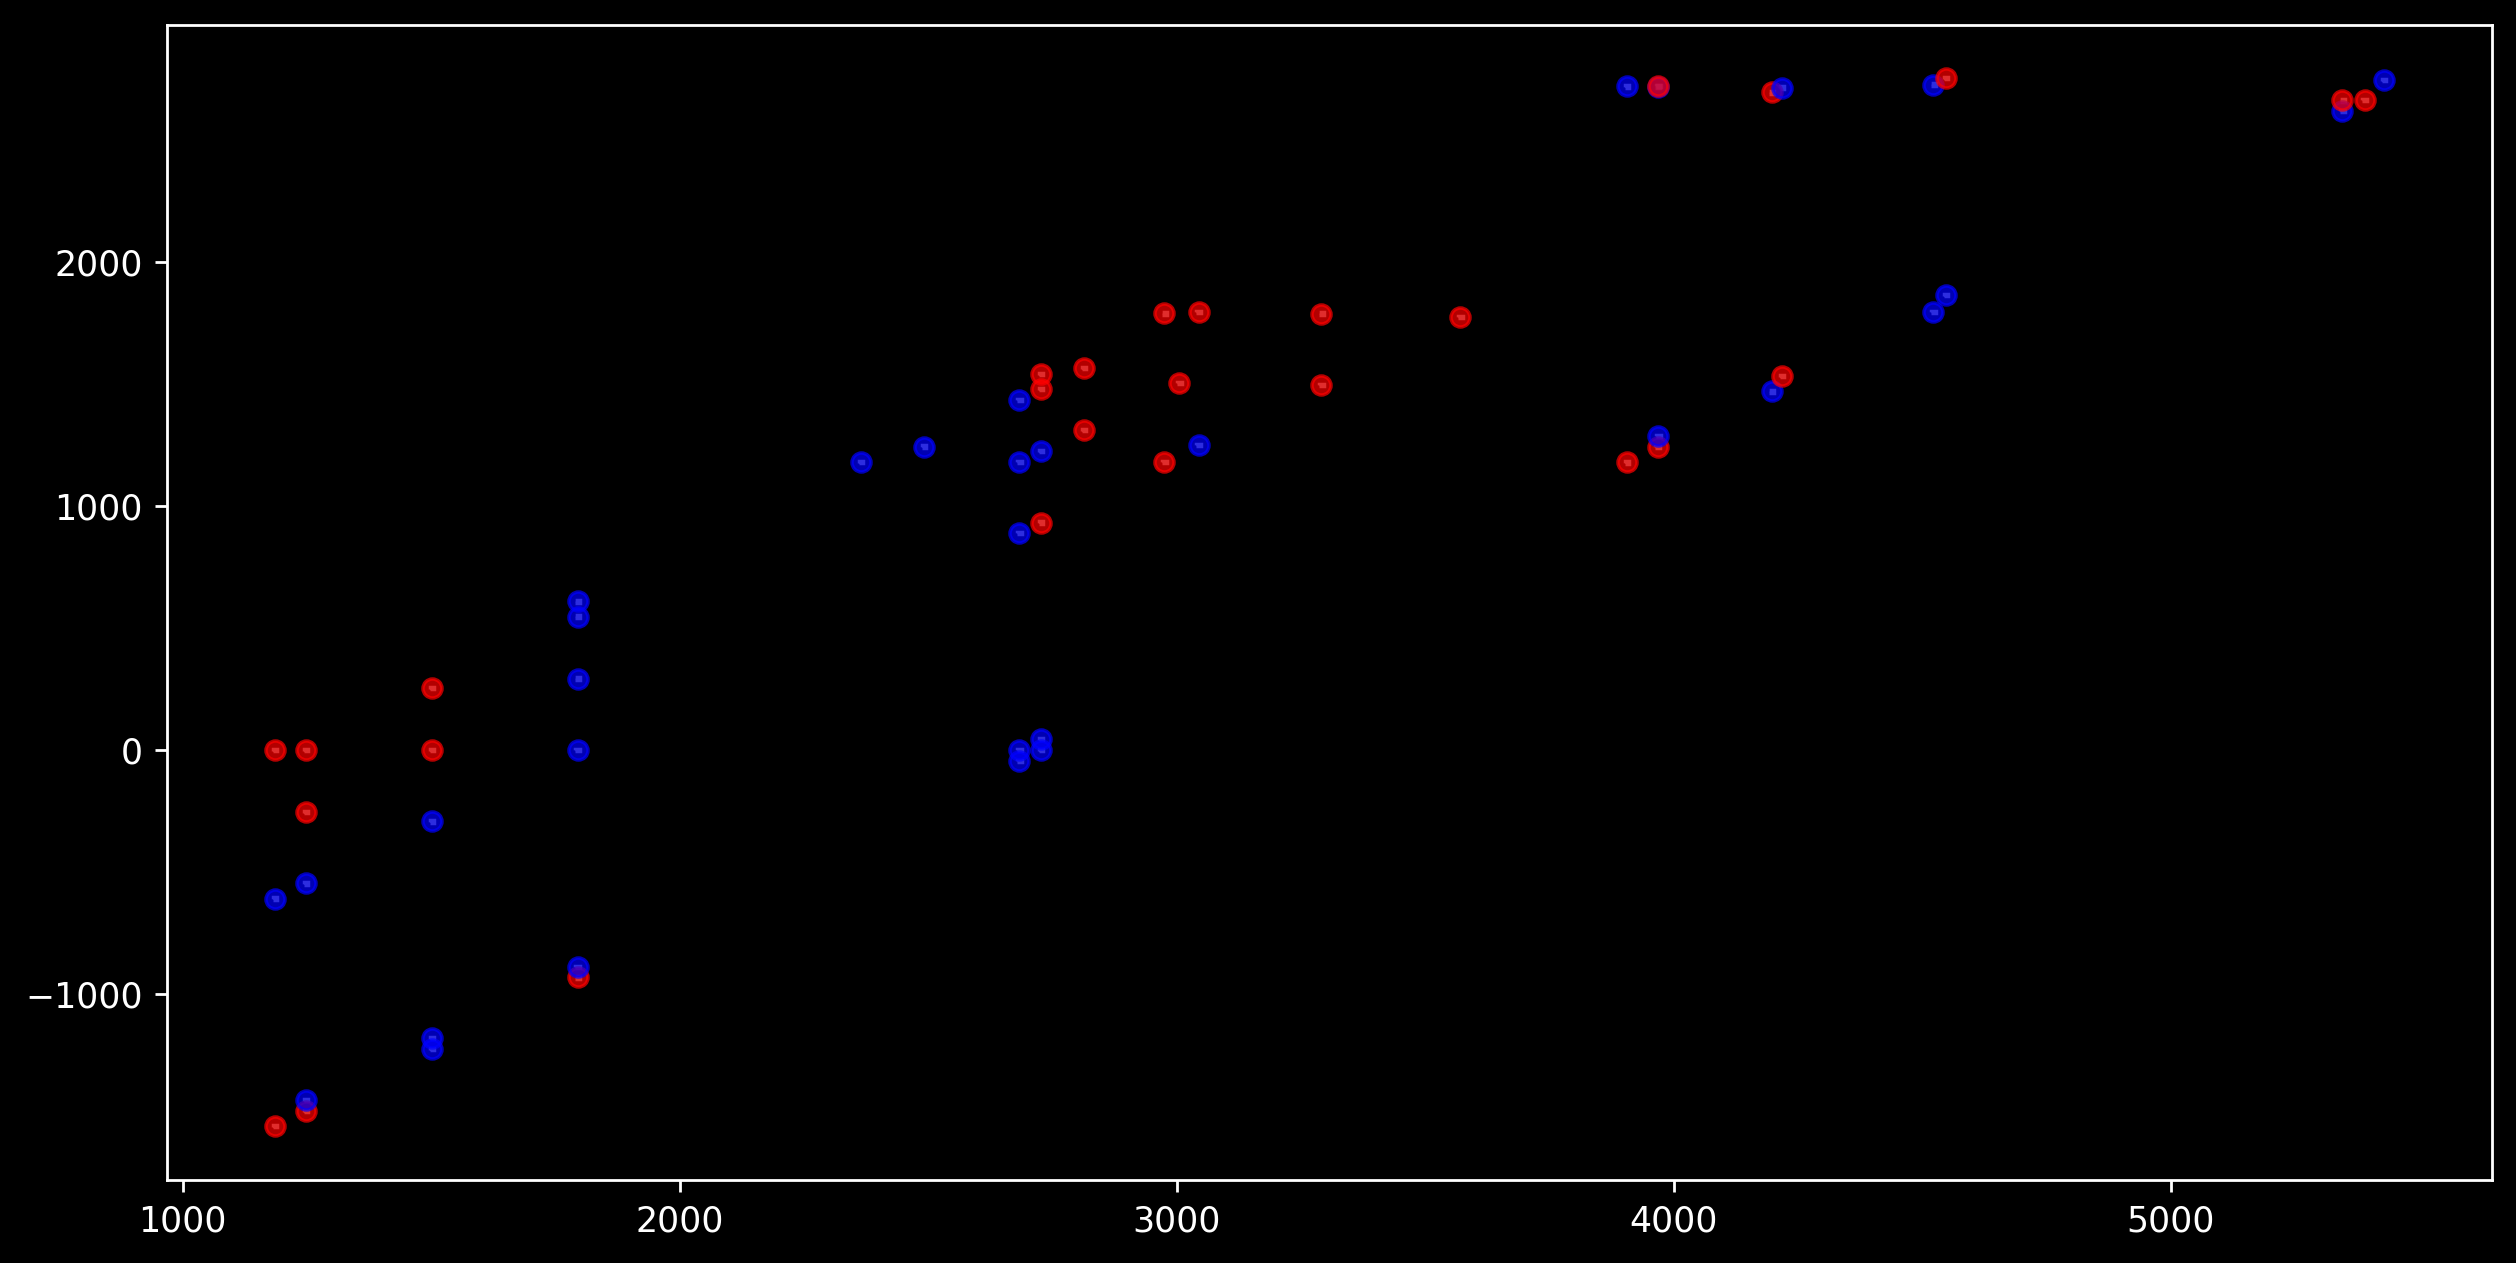

In [29]:
fig, ax = plt.subplots(figsize=(12, 6), dpi=250)
plot_features(ax, features)

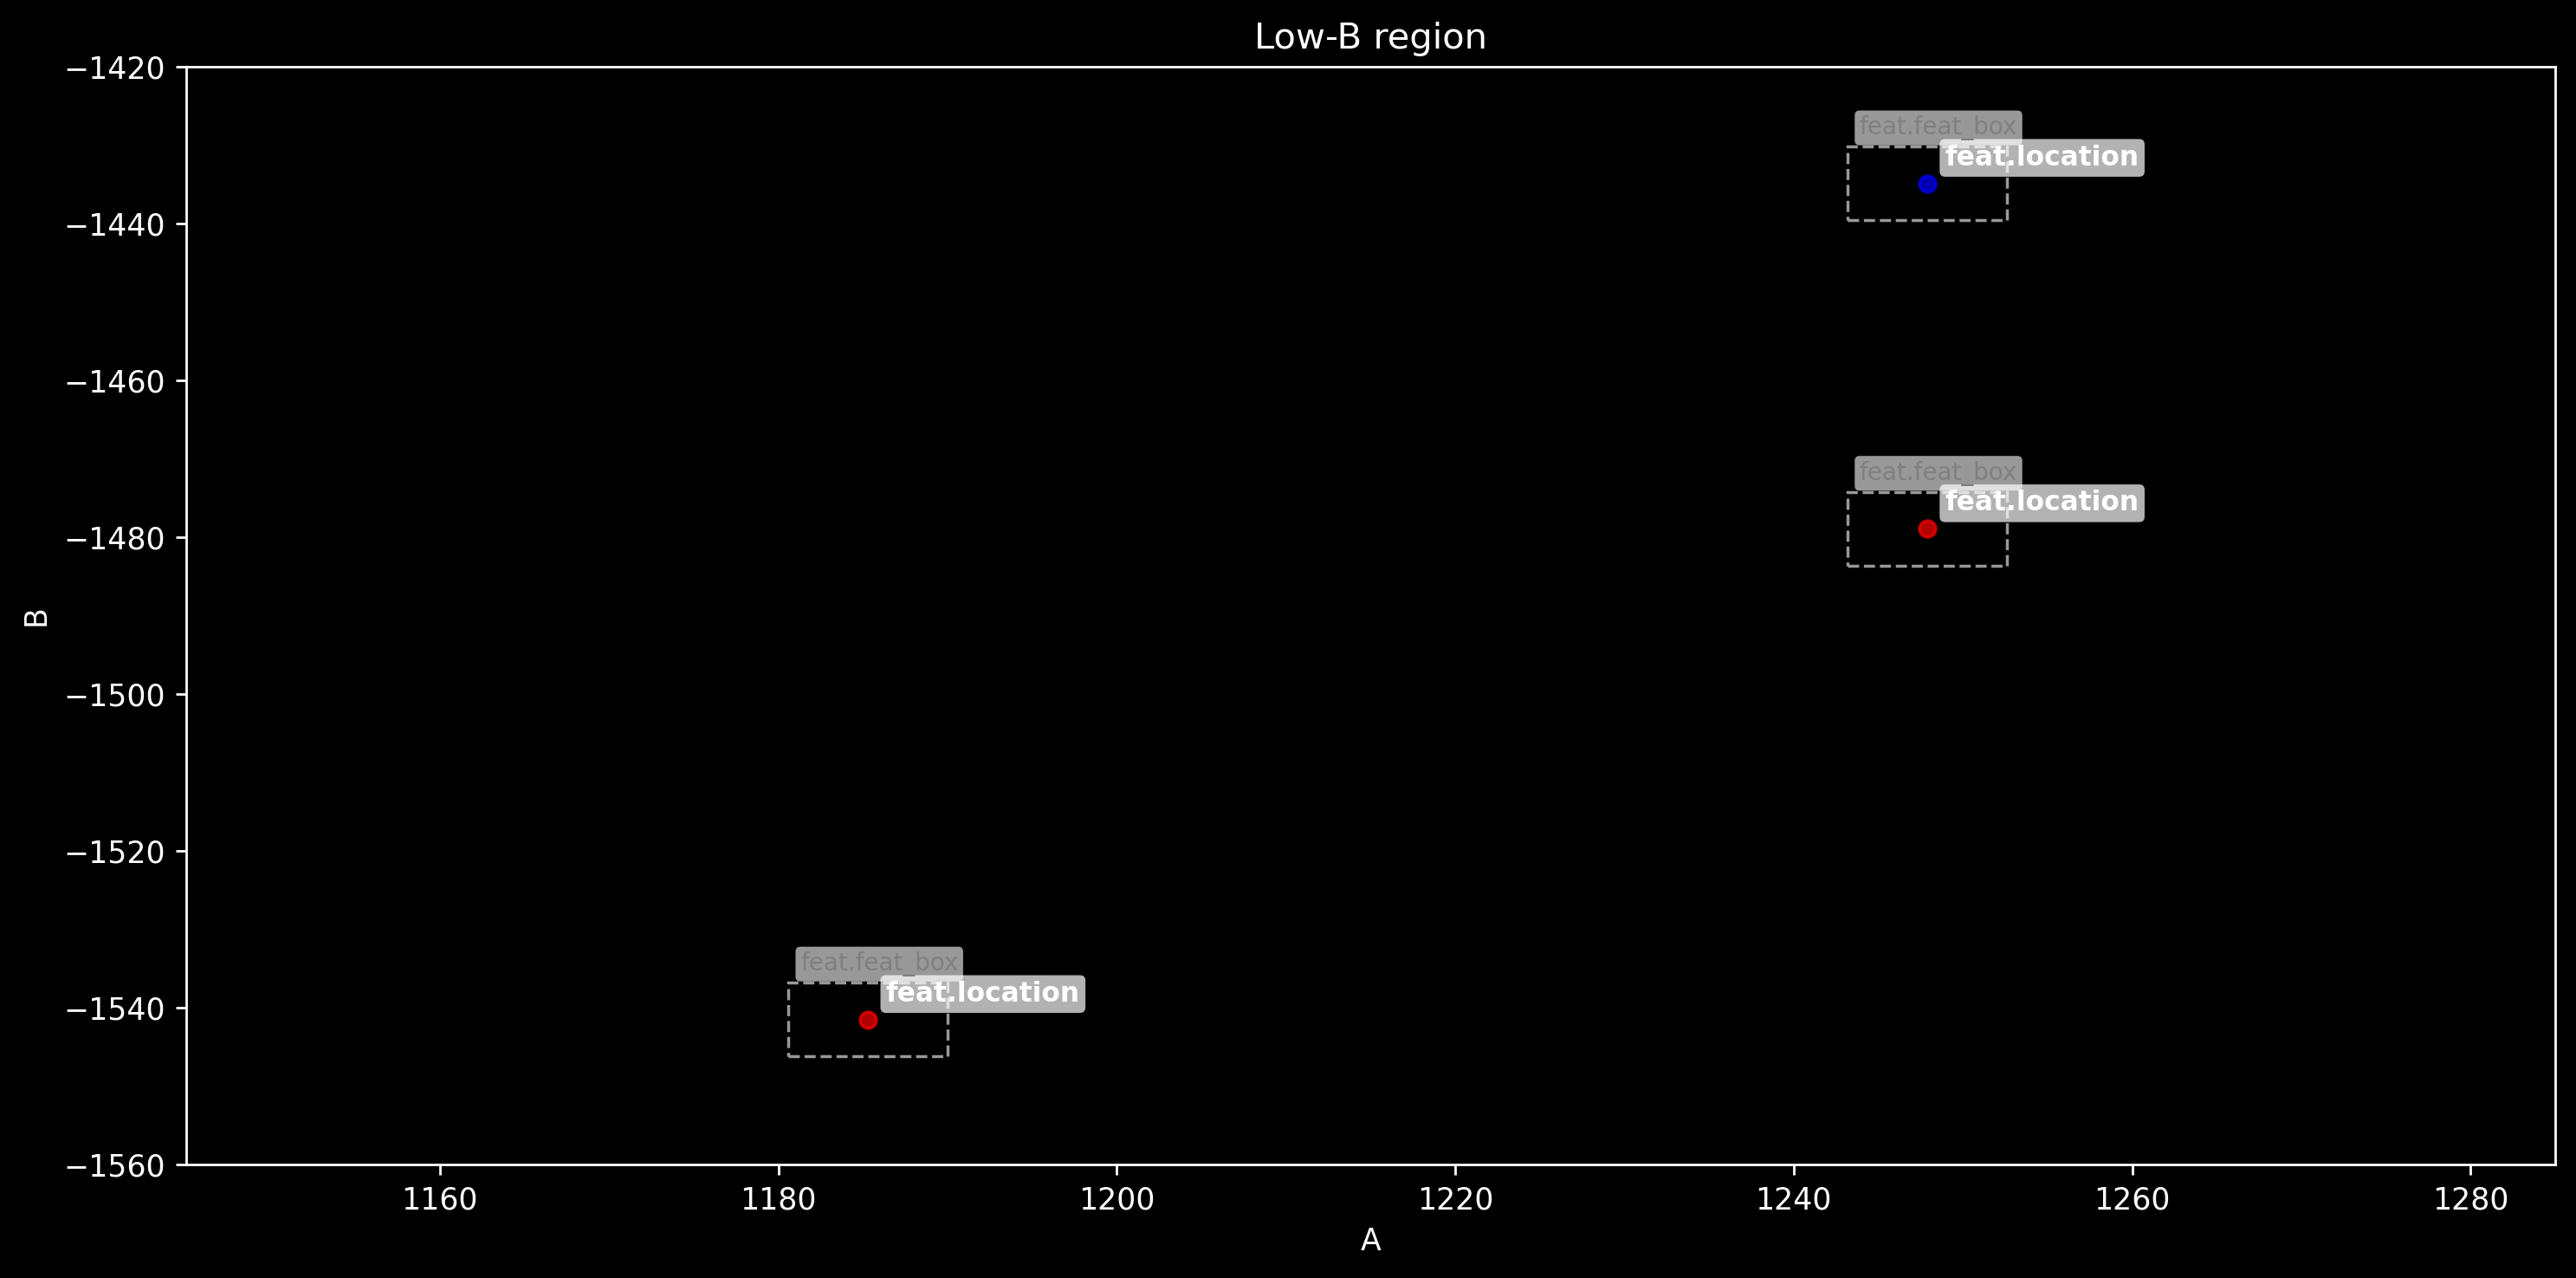

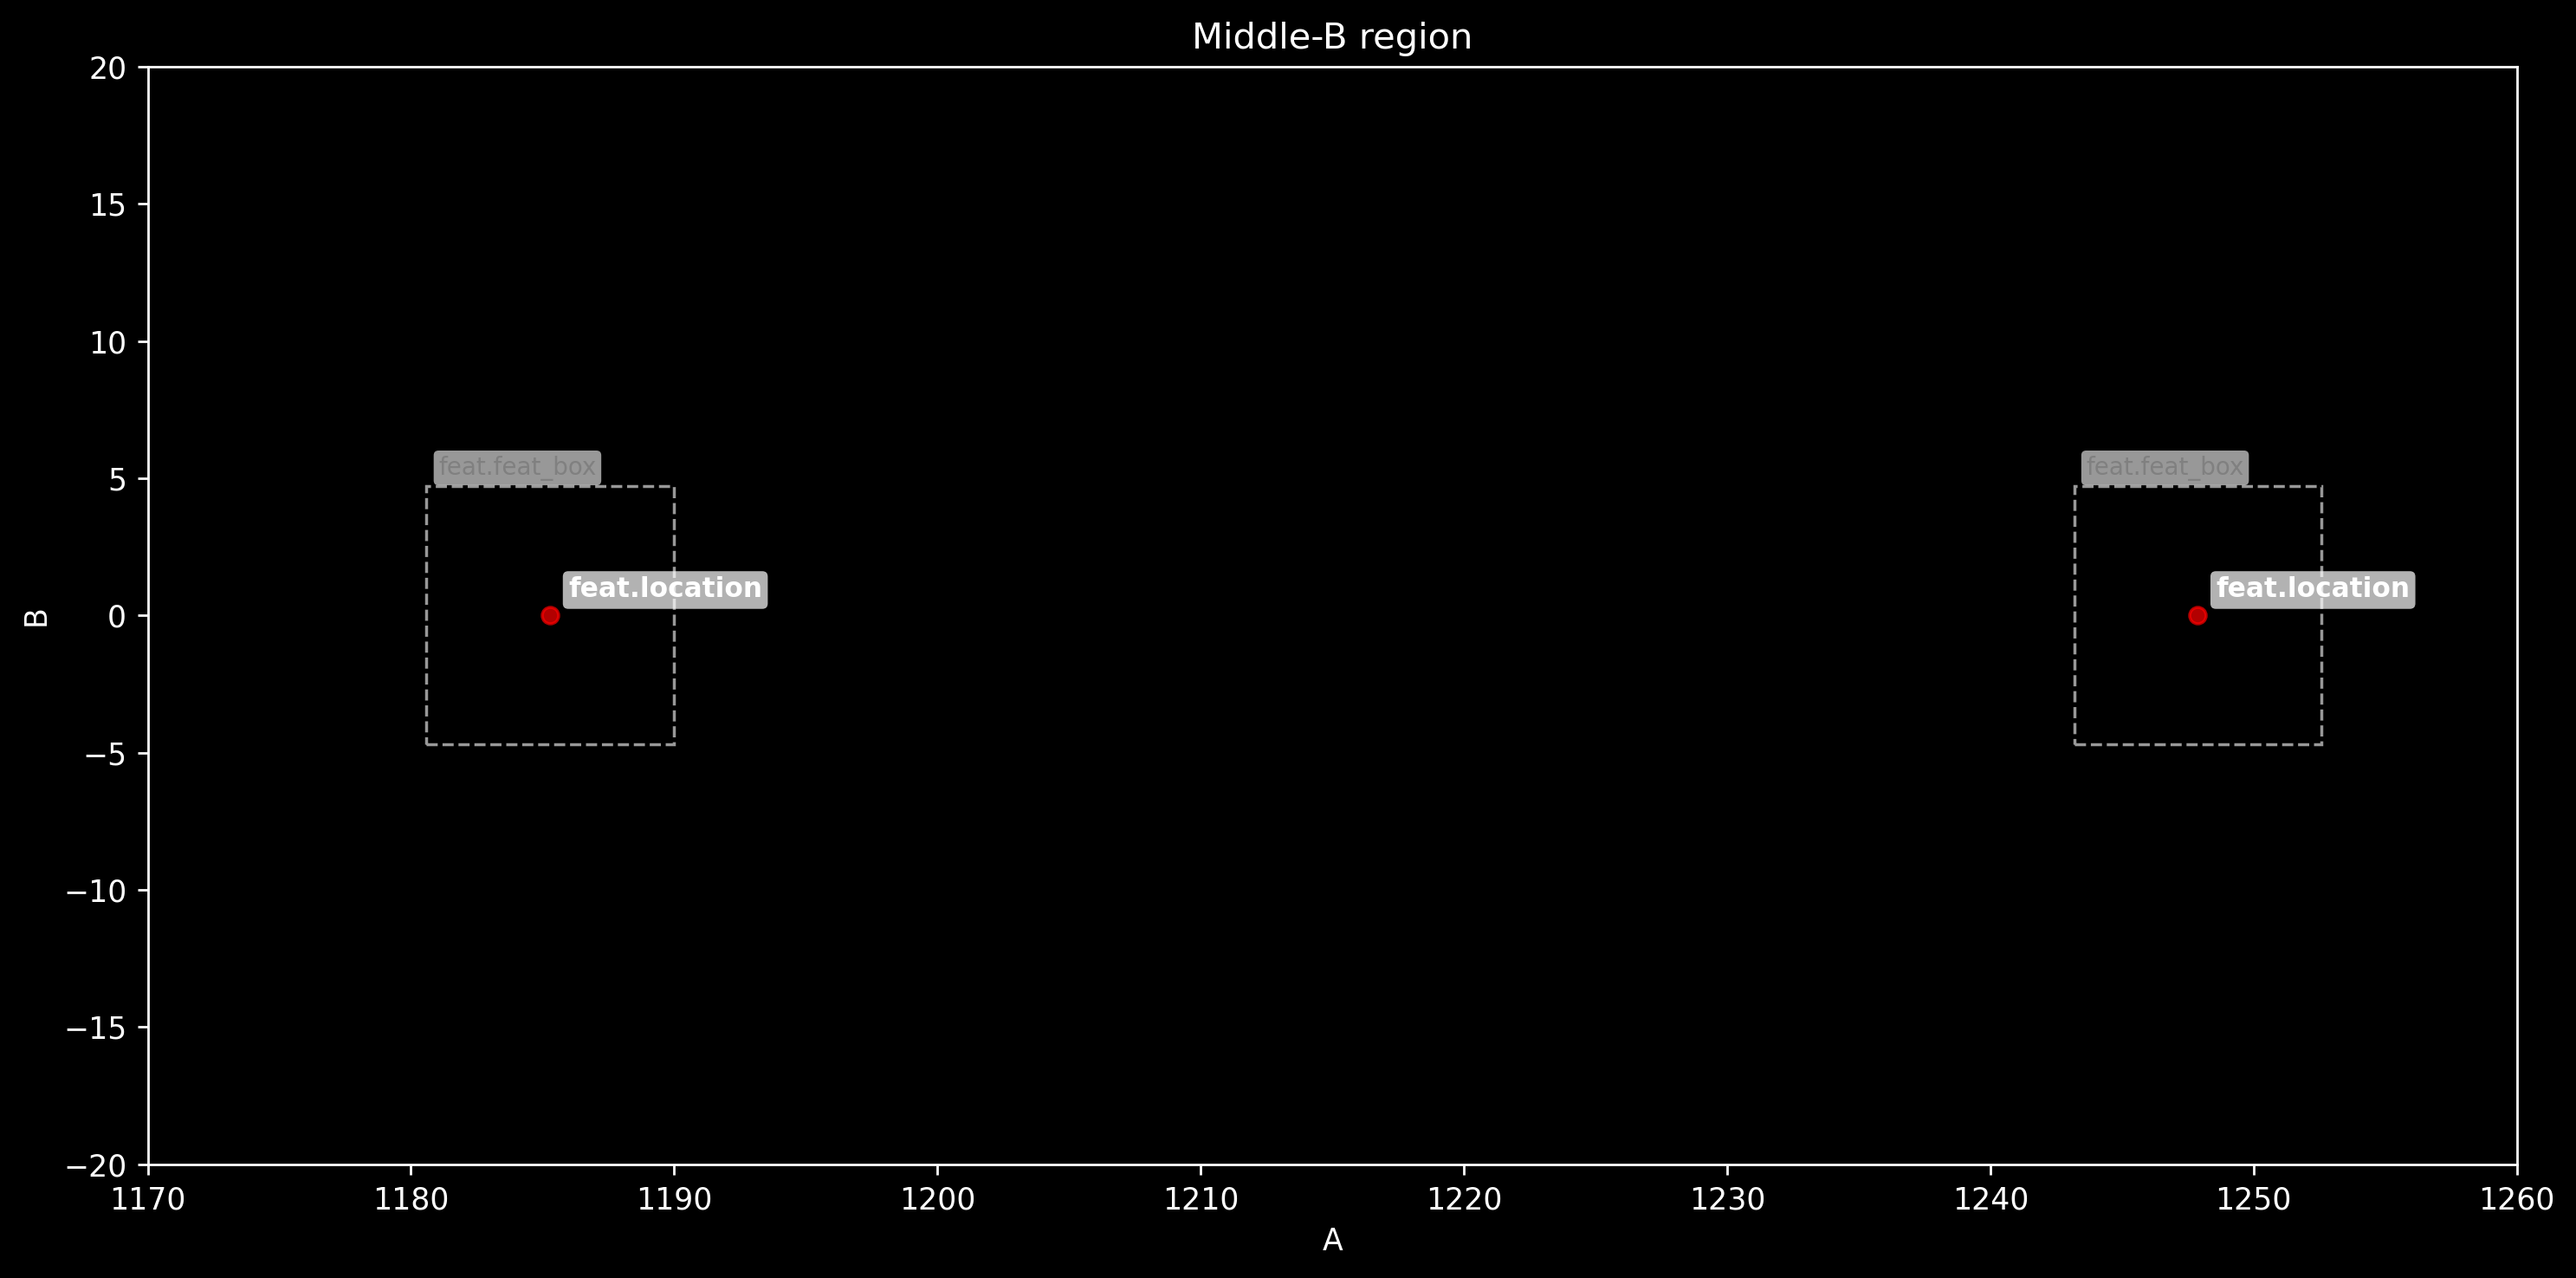

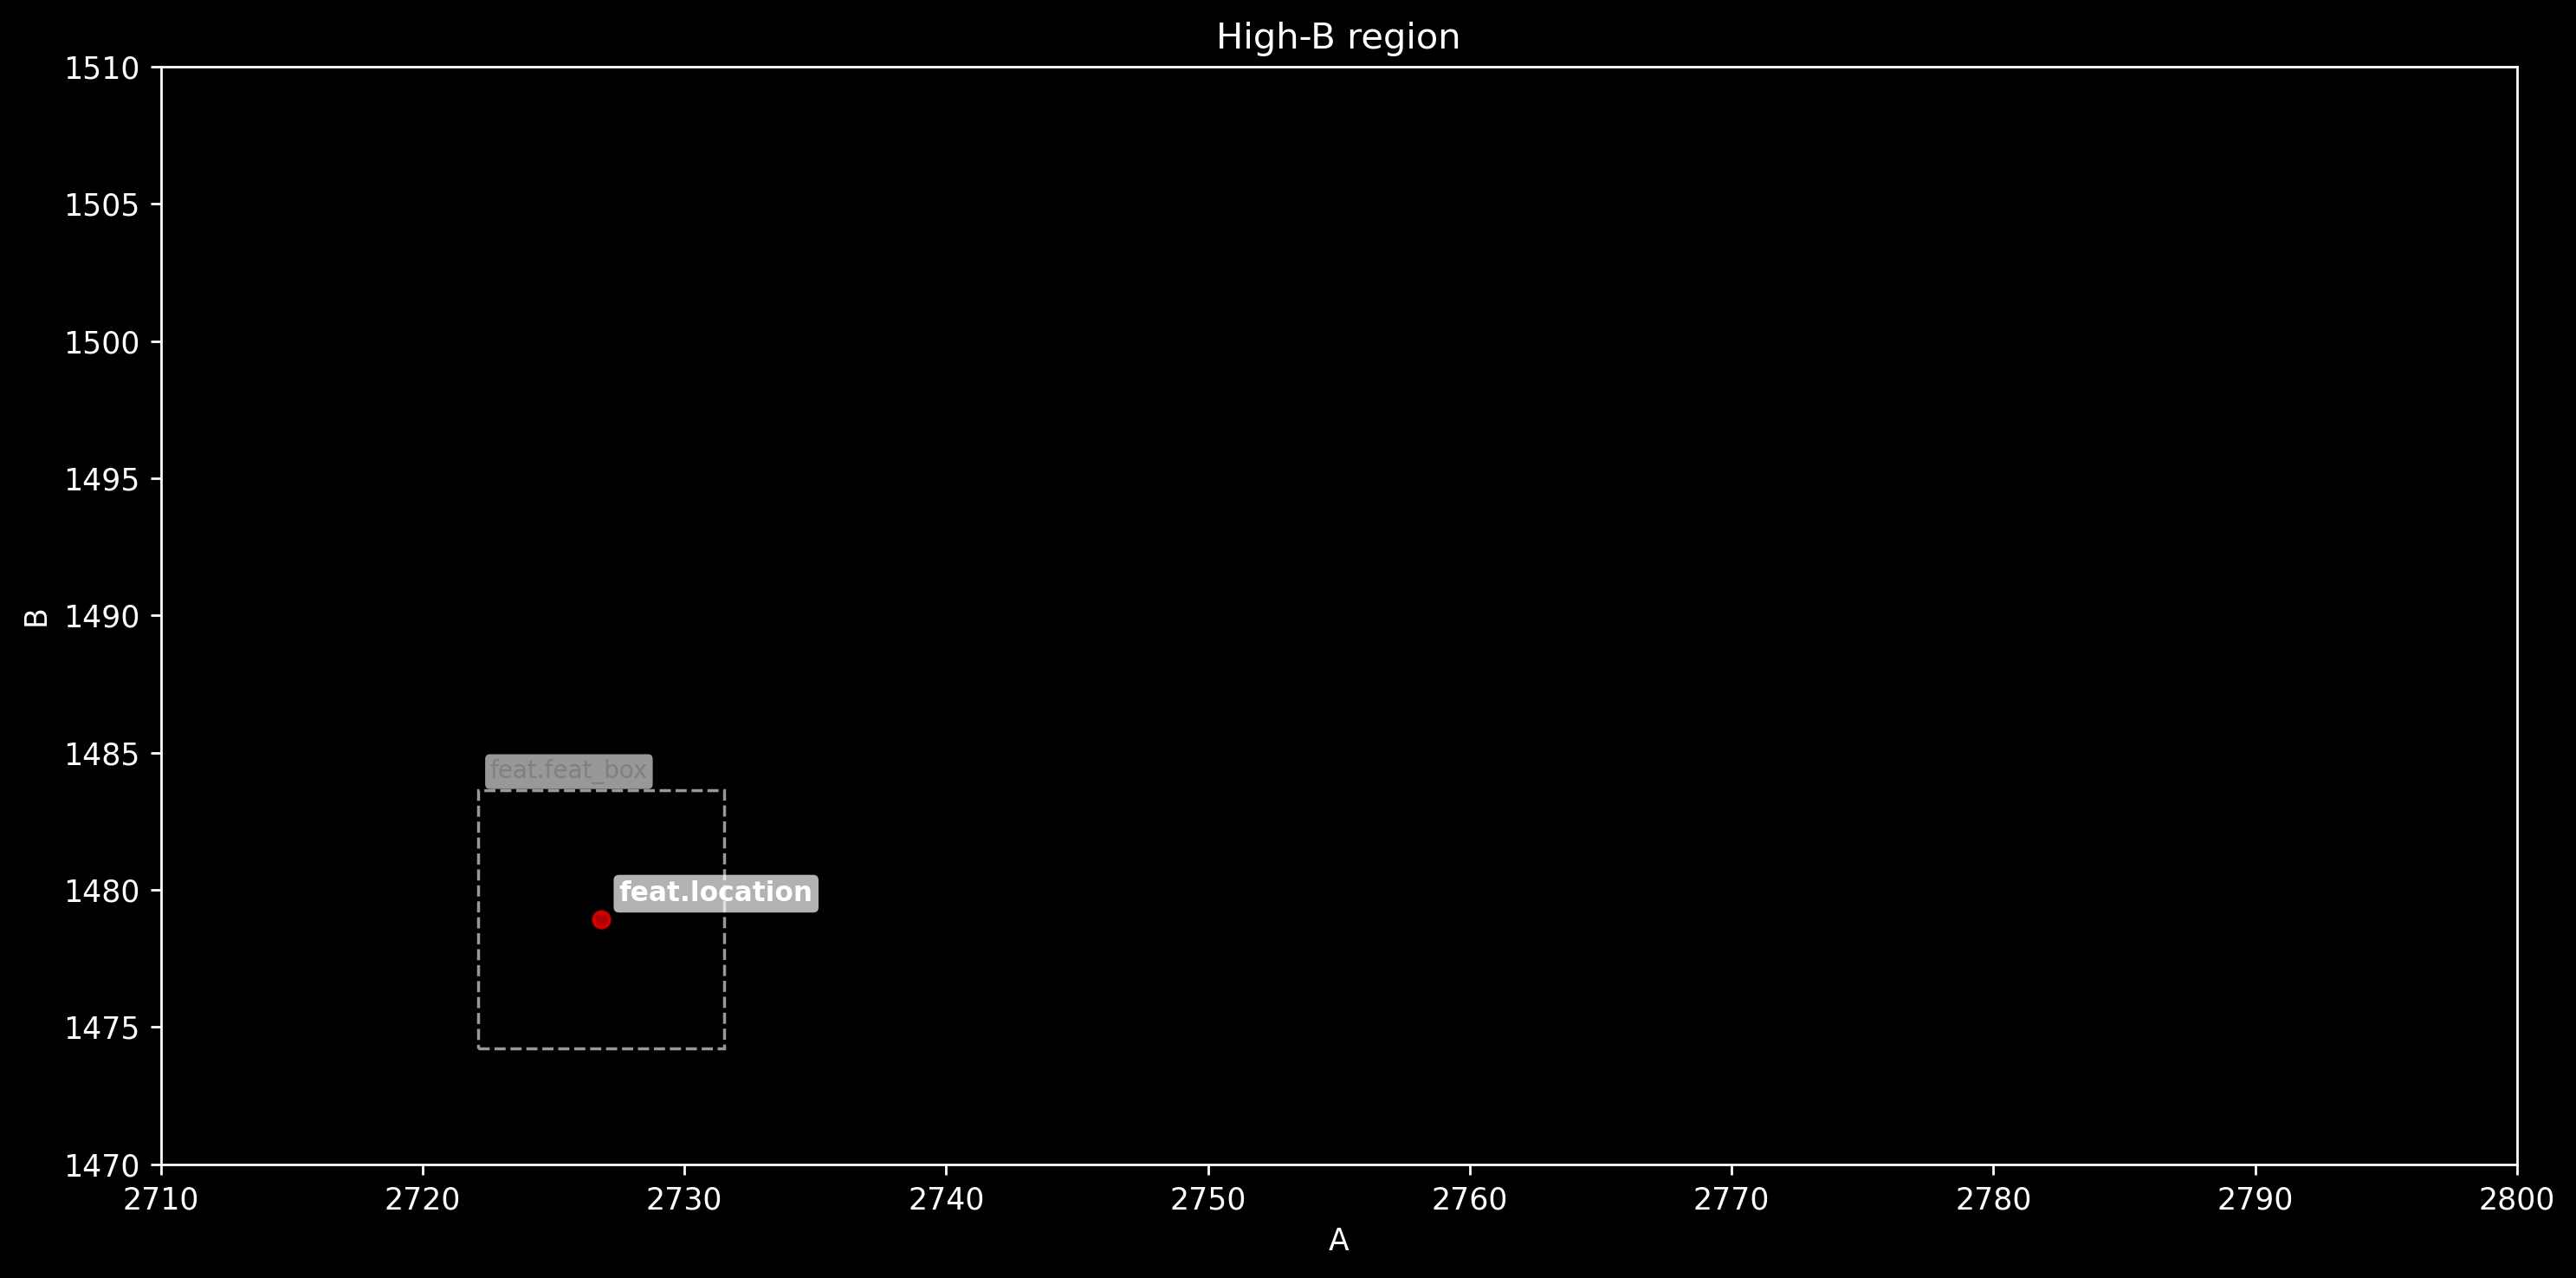

In [30]:
regions = [
    dict(xlim=(1145., 1285.), ylim=(-1560., -1420.), title="Low-B region"),
    dict(xlim=(1170., 1260.), ylim=(-20., 20.), title="Middle-B region"),
    dict(xlim=(2710., 2800.), ylim=(1470., 1510.), title="High-B region"),
]

for region in regions:
    fig, ax = plt.subplots(figsize=(12, 6), dpi=250)

    plot_features(ax, features, region, annotate=True)

    ax.set_xlim(*region["xlim"])
    ax.set_ylim(*region["ylim"])
    ax.set_xlabel("A")
    ax.set_ylabel("B")
    ax.set_title(region["title"])

    plt.tight_layout()
    plt.show()

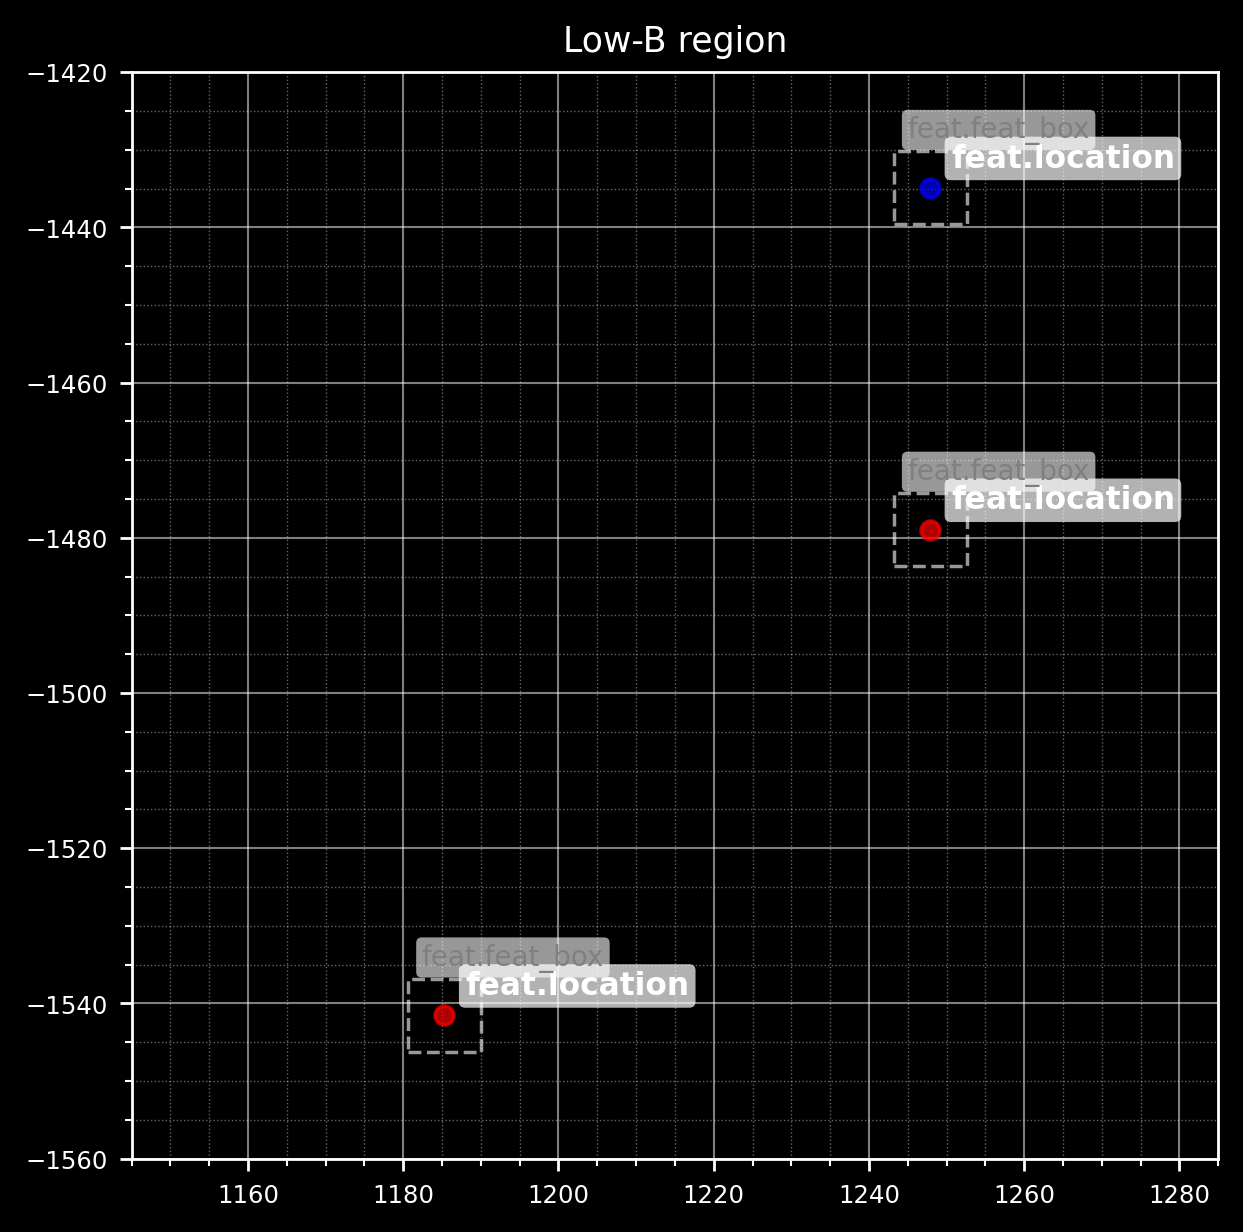

In [31]:
from matplotlib.ticker import MultipleLocator
with plt.rc_context({
    "font.size": 8,
    "axes.titlesize": 10,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
}):
    fig, ax = plt.subplots(figsize=(5, 5), dpi=250)

    plot_features(ax, features, regions[0], annotate=True)

    # limits
    ax.set_xlim(1145., 1285.)
    ax.set_ylim(-1560., -1420.)

    # square grid
    xrange = 1285. - 1145.
    yrange = -1420. - (-1560.)
    ax.set_aspect(xrange / yrange)

    # ticks
    ax.xaxis.set_major_locator(MultipleLocator(20))
    ax.yaxis.set_major_locator(MultipleLocator(20))
    ax.xaxis.set_minor_locator(MultipleLocator(5))
    ax.yaxis.set_minor_locator(MultipleLocator(5))

    # grid
    ax.grid(True, which="major", linestyle="-", linewidth=0.6, alpha=0.5)
    ax.grid(True, which="minor", linestyle=":", linewidth=0.4, alpha=0.4)

    ax.set_title("Low-B region")
    plt.tight_layout()
    plt.show()

### Spectral window (with Features after Step 6)

In [32]:
simulation.spec_eval_setup.ev_info.spectral_window

SpectralWindow(box=Box(bounds={'A': (0.0, 5000.0), 'B': (0.0, 5000.0)}, grid=None, has_grid=False), full_features=[], contrib_features=[])

In [33]:
def plot_spec_window(spec_window, point_size=30):
    with plt.rc_context({
        "font.size": 8,
        "axes.titlesize": 8,
        "axes.labelsize": 6,
        "xtick.labelsize": 6,
        "ytick.labelsize": 6,
    }):
        fig, ax = plt.subplots(figsize=(2, 2), dpi=250)
        ax.set_xlim(*spec_window.box.bounds['B'])
        ax.set_ylim(*spec_window.box.bounds['A'])
        if spec_window.full_features:
            title = 'SpectralWindow with Features'
        else:
            title = 'SpectralWindow'

        plt.title(title)

        plot_features(ax, spec_window.full_features, point_size=point_size)

        plt.show()

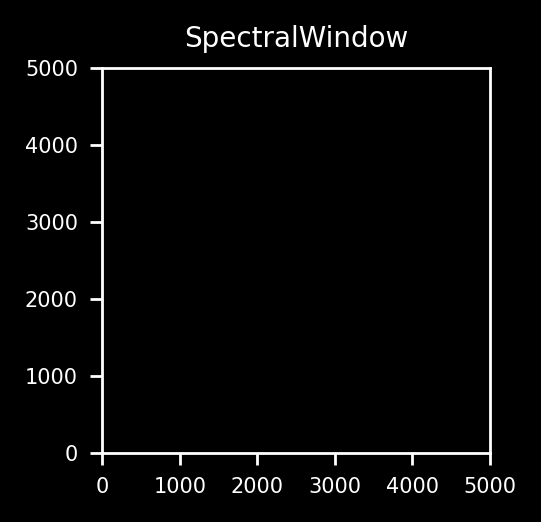

In [34]:
plot_spec_window(simulation.spec_eval_setup.ev_info.spectral_window)

In [35]:
results.spec_window.full_features

[SpectralFeature(location=Point(A=4522.216, B=1795.4030000000002), term_contributions=(TermParametersChoice(res_motif=[ResCond(diff = [sl=omega_[], sr=omega_['a']], pert_wf=F, pf = ['-A', 'B'], id = None), ResCond(diff = [sl=omega_['a', 'b'], sr=omega_['a']], pert_wf=F, pf = ['B'], id = None)], states_parameters=(ParameterSet({'a': 0, 'b': 1}),), term_ids=(2745459714091790811, -8755679830028948260, -3191875566568694723, -1623549071989627856, -58159830087338244, -1576179026341646674, 8915377813582365302)),), lineshape_parameter=4.7, amplitude_coeff=-8.914647823023665e-05, feat_type='full', feat_box=Box(bounds={'A': (4517.5160000000005, 4526.916), 'B': (1790.7030000000002, 1800.1030000000003)}, grid=None, has_grid=False)),
 SpectralFeature(location=Point(A=4197.002, B=1470.1890000000003), term_contributions=(TermParametersChoice(res_motif=[ResCond(diff = [sl=omega_[], sr=omega_['a']], pert_wf=F, pf = ['-A', 'B'], id = None), ResCond(diff = [sl=omega_['a', 'b'], sr=omega_['a']], pert_wf=F

In [36]:
results.spec_window.contrib_features

[]

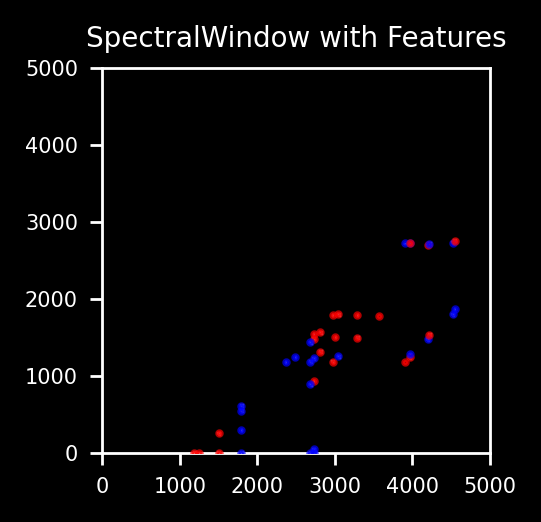

In [37]:
plot_spec_window(results.spec_window, point_size=2)

### GridManager and full_grid (after Step 7)

In [38]:
gr_mng = results.grid_manager
type(gr_mng)
cp_mng = copy.copy(gr_mng)
cp_mng.__dict__.keys()
cp_mng.spec_window.full_features = []
cp_mng

GridManager(spec_window=SpectralWindow(box=Box(bounds={'A': (0.0, 5000.0), 'B': (0.0, 5000.0)}, grid=None, has_grid=False), full_features=[], contrib_features=[]))

In [39]:
results.grid_manager.__dict__.keys()

dict_keys(['spec_window', 'coords_vectors', 'full_grid'])

In [40]:
results.grid_manager.spec_window

SpectralWindow(box=Box(bounds={'A': (0.0, 5000.0), 'B': (0.0, 5000.0)}, grid=None, has_grid=False), full_features=[], contrib_features=[])

In [41]:
results.grid_manager.coords_vectors

{'A': array([   0.,  550., 1100., 1650., 2200., 2750., 3300., 3850., 4400., 4950.]),
 'B': array([   0.,  550., 1100., 1650., 2200., 2750., 3300., 3850., 4400., 4950.])}

In [42]:
results.grid_manager.full_grid

{'A': array([[   0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.],
        [ 550.,  550.,  550.,  550.,  550.,  550.,  550.,  550.,  550.,  550.],
        [1100., 1100., 1100., 1100., 1100., 1100., 1100., 1100., 1100., 1100.],
        [1650., 1650., 1650., 1650., 1650., 1650., 1650., 1650., 1650., 1650.],
        [2200., 2200., 2200., 2200., 2200., 2200., 2200., 2200., 2200., 2200.],
        [2750., 2750., 2750., 2750., 2750., 2750., 2750., 2750., 2750., 2750.],
        [3300., 3300., 3300., 3300., 3300., 3300., 3300., 3300., 3300., 3300.],
        [3850., 3850., 3850., 3850., 3850., 3850., 3850., 3850., 3850., 3850.],
        [4400., 4400., 4400., 4400., 4400., 4400., 4400., 4400., 4400., 4400.],
        [4950., 4950., 4950., 4950., 4950., 4950., 4950., 4950., 4950., 4950.]]),
 'B': array([[   0.,  550., 1100., 1650., 2200., 2750., 3300., 3850., 4400., 4950.],
        [   0.,  550., 1100., 1650., 2200., 2750., 3300., 3850., 4400., 4950.],
        [   0.,  550., 1100.

#### full_grid setup

In [43]:
grid = results.grid_manager.full_grid

A, B = grid["A"], grid["B"]   # shape (10, 10)
Z = grid["result"]           # shape (10, 10), complex

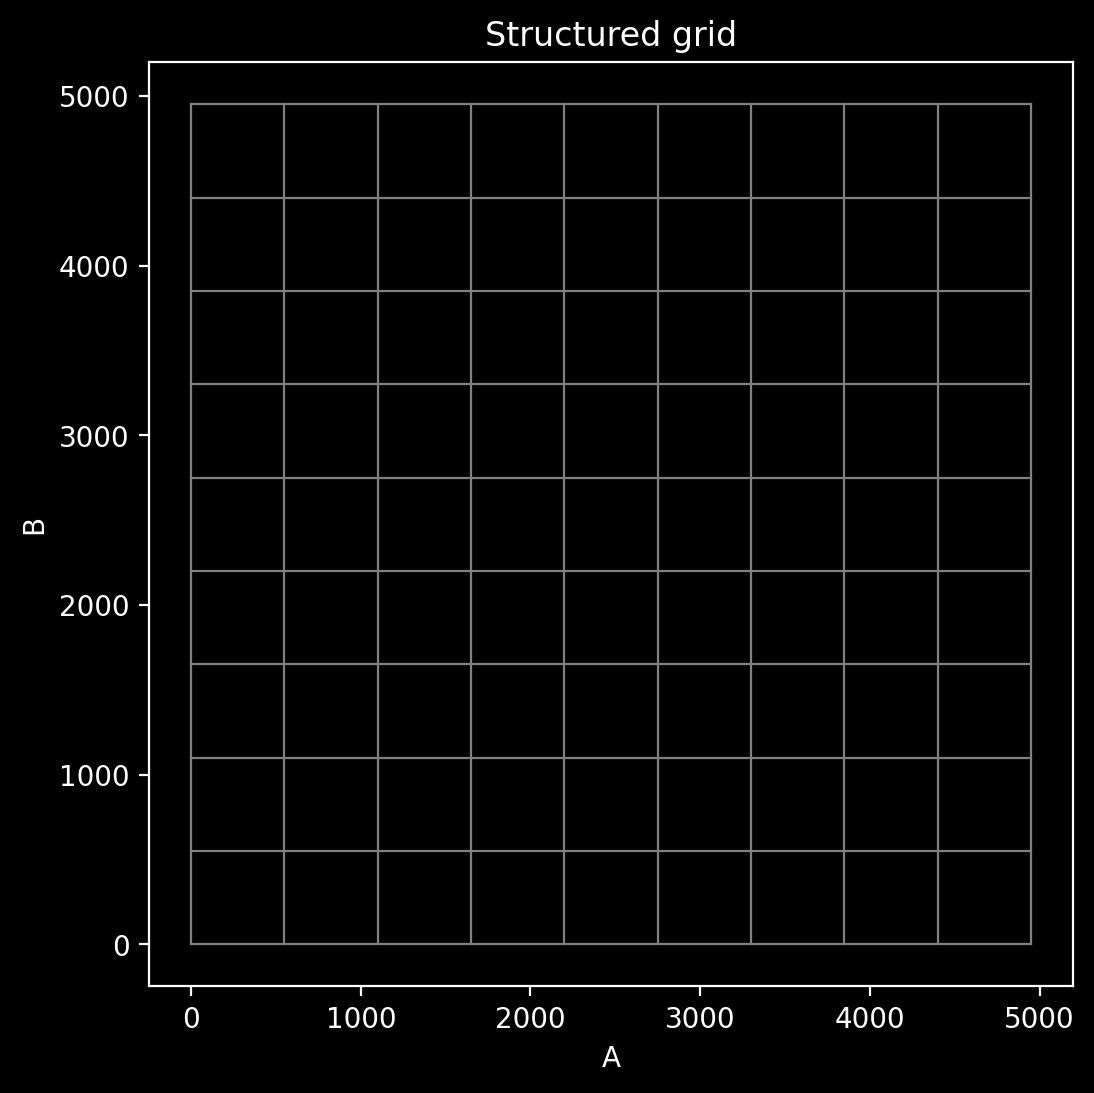

In [44]:
fig, ax = plt.subplots(figsize=(6, 6), dpi=200)

for i in range(A.shape[0]):
    ax.plot(A[i, :], B[i, :], color="gray", linewidth=0.8)

for j in range(A.shape[1]):
    ax.plot(A[:, j], B[:, j], color="gray", linewidth=0.8)

ax.scatter(A, B, s=15, color="black")

ax.set_aspect("equal")
ax.set_xlabel("A")
ax.set_ylabel("B")
ax.set_title("Structured grid")

plt.show()


#### full_grid results

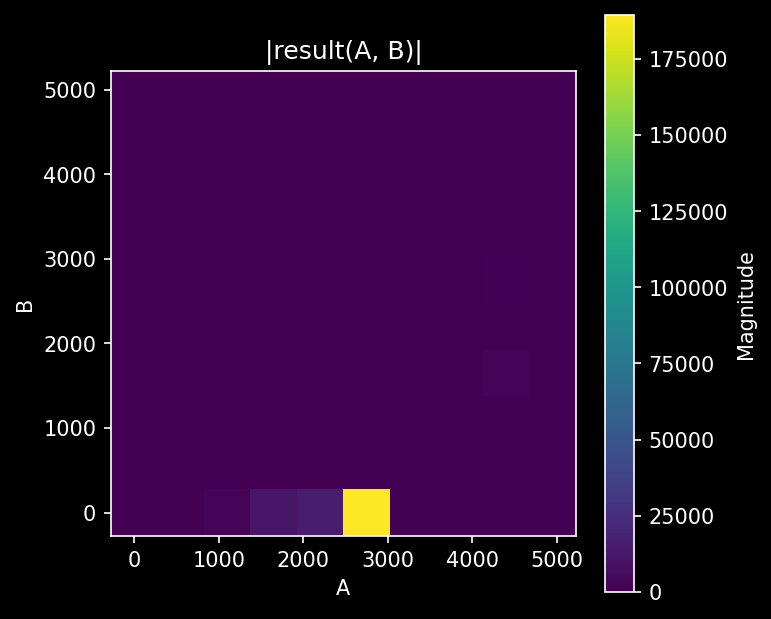

In [45]:
Zabs = abs(grid["result"])

fig, ax = plt.subplots(figsize=(5, 5), dpi=150)

im = ax.pcolormesh(
    A,
    B,
    Zabs,
    shading="nearest"
)

ax.set_xlabel("A")
ax.set_ylabel("B")
ax.set_title("|result(A, B)|")

ax.set_aspect("equal")
fig.colorbar(im, ax=ax, label="Magnitude")

plt.show()

### GridRegion (regions are found in Step 8)

GridRegion has a domain - RectangularDomain

RectangularDomain has a box

In [46]:
results.regions[0]

GridRegion(domain=RectangularDomain(box=Box(bounds={'A': (4517.5160000000005, 4526.916), 'B': (1790.7030000000002, 1800.1030000000003)}, grid=None, has_grid=False), full_features=[SpectralFeature(location=Point(A=4522.216, B=1795.4030000000002), term_contributions=(TermParametersChoice(res_motif=[ResCond(diff = [sl=omega_[], sr=omega_['a']], pert_wf=F, pf = ['-A', 'B'], id = None), ResCond(diff = [sl=omega_['a', 'b'], sr=omega_['a']], pert_wf=F, pf = ['B'], id = None)], states_parameters=(ParameterSet({'a': 0, 'b': 1}),), term_ids=(2745459714091790811, -8755679830028948260, -3191875566568694723, -1623549071989627856, -58159830087338244, -1576179026341646674, 8915377813582365302)),), lineshape_parameter=4.7, amplitude_coeff=-8.914647823023665e-05, feat_type='full', feat_box=Box(bounds={'A': (4517.5160000000005, 4526.916), 'B': (1790.7030000000002, 1800.1030000000003)}, grid=None, has_grid=False))], contrib_features=[]), coords={'A': array([[4400., 4400.],
       [4950., 4950.]]), 'B': a

In [47]:
results.regions[0].__dict__.keys()

dict_keys(['domain', 'coords', 'indices', 'region_id'])

In [48]:
results.regions[0].domain

RectangularDomain(box=Box(bounds={'A': (4517.5160000000005, 4526.916), 'B': (1790.7030000000002, 1800.1030000000003)}, grid=None, has_grid=False), full_features=[SpectralFeature(location=Point(A=4522.216, B=1795.4030000000002), term_contributions=(TermParametersChoice(res_motif=[ResCond(diff = [sl=omega_[], sr=omega_['a']], pert_wf=F, pf = ['-A', 'B'], id = None), ResCond(diff = [sl=omega_['a', 'b'], sr=omega_['a']], pert_wf=F, pf = ['B'], id = None)], states_parameters=(ParameterSet({'a': 0, 'b': 1}),), term_ids=(2745459714091790811, -8755679830028948260, -3191875566568694723, -1623549071989627856, -58159830087338244, -1576179026341646674, 8915377813582365302)),), lineshape_parameter=4.7, amplitude_coeff=-8.914647823023665e-05, feat_type='full', feat_box=Box(bounds={'A': (4517.5160000000005, 4526.916), 'B': (1790.7030000000002, 1800.1030000000003)}, grid=None, has_grid=False))], contrib_features=[])

In [49]:
results.regions[0].coords

{'A': array([[4400., 4400.],
        [4950., 4950.]]),
 'B': array([[1650., 2200.],
        [1650., 2200.]])}

In [50]:
results.regions[0].indices

(slice(np.int64(8), np.int64(10), None), slice(np.int64(3), np.int64(5), None))

In [51]:
results.regions[0].region_id

0

### RectangularDomain

In [52]:
domain = results.regions[0].domain

In [53]:
cp_domain = copy.copy(domain)
cp_domain.__dict__.keys()
cp_domain.full_features = []
cp_domain

RectangularDomain(box=Box(bounds={'A': (4517.5160000000005, 4526.916), 'B': (1790.7030000000002, 1800.1030000000003)}, grid=None, has_grid=False), full_features=[], contrib_features=[])

In [54]:
domain.__dict__.keys()

dict_keys(['box', 'full_features', 'contrib_features'])

In [55]:
domain.box

Box(bounds={'A': (4517.5160000000005, 4526.916), 'B': (1790.7030000000002, 1800.1030000000003)}, grid=None, has_grid=False)

In [56]:
domain.full_features

[SpectralFeature(location=Point(A=4522.216, B=1795.4030000000002), term_contributions=(TermParametersChoice(res_motif=[ResCond(diff = [sl=omega_[], sr=omega_['a']], pert_wf=F, pf = ['-A', 'B'], id = None), ResCond(diff = [sl=omega_['a', 'b'], sr=omega_['a']], pert_wf=F, pf = ['B'], id = None)], states_parameters=(ParameterSet({'a': 0, 'b': 1}),), term_ids=(2745459714091790811, -8755679830028948260, -3191875566568694723, -1623549071989627856, -58159830087338244, -1576179026341646674, 8915377813582365302)),), lineshape_parameter=4.7, amplitude_coeff=-8.914647823023665e-05, feat_type='full', feat_box=Box(bounds={'A': (4517.5160000000005, 4526.916), 'B': (1790.7030000000002, 1800.1030000000003)}, grid=None, has_grid=False))]

In [57]:
domain.contrib_features

[]